# Jaw Keypoint Training

Notebook wrapper around [`train.py`](train.py). Trains **one shared model** on all three conditions.

Requires merged splits from `Create Dataset/create_dataset.py`:
`../data/train.pkl` and `../data/val.pkl`.

Training batches are shuffled **within each condition only** (never mixed across conditions).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(Path.cwd()))
from train import default_training_config, run_training

In [2]:
config = default_training_config(
    train_pkl="../data/train.pkl",
    val_pkl="../data/val.pkl",
    out_dir="./checkpoints",
    epochs=200,
    batch_size=16,
    lr=1e-3,
    weight_decay=1e-4,
    num_workers=4,
    img_h=240,
    img_w=320,
    window_size=4,
    temporal_hidden=384,
    temporal_layers=3,
    decoder_hidden=512,
    edge_mode="pad",
    no_require_consecutive=False,
    no_freeze_backbone=False,
    unfreeze_backbone_epoch=0,
    coord_weight=1.0,
    tip_coord_weight=2.0,
    occluded_tip_weight=0.25,
    relative_offset_weight=0.5,
    patience=20,
    seed=42,
)

print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Train: {config.train_pkl}")
print(f"Val:   {config.val_pkl}")
print(f"Out:   {config.out_dir}")
print(f"Loss: focal + coord (tip {config.tip_coord_weight}×) + rel offset ({config.relative_offset_weight}×)")
print(f"Occluded tip weight (BiPoles): {config.occluded_tip_weight}")
print(f"Backbone: frozen for full run")
print(f"Checkpoint/early stop: patience={config.patience} on BiPoles val_rmse_mean")

Device: cuda
Train: ../data/train.pkl
Val:   ../data/val.pkl
Out:   ./checkpoints
Loss: focal + coord (tip 2.0×) + rel offset (0.5×)
Occluded tip weight (BiPoles): 0.25
Backbone: frozen for full run
Checkpoint/early stop: patience=20 on BiPoles val_rmse_mean


In [3]:
result = run_training(config)


Training shared model on all conditions
Train: ../data/train.pkl
Val:   ../data/val.pkl
Backbone: frozen (unfreeze disabled)
Occluded tip weight (BiPoles): 0.25
Early stopping: patience=20 on bipoles_rmse_mean


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Model parameters: 14,426,500


Epoch 1 val: 100%|██████████| 107/107 [00:13<00:00,  7.71batch/s, coord=0.005, loss=0.010, rel=0.010]


Epoch 1/200  train_loss=0.0275  bipoles_rmse=16.5px  best=16.5px  *saved*  global_rmse=23.9px  [IRt_BiPoles=27.7  IRt_TeLC=37.0  PCRt_BiPoles=10.7]


...

Epoch 3/200  train_loss=0.0120  bipoles_rmse=15.8px  best=15.8px  *saved*  global_rmse=12.8px  [IRt_BiPoles=16.7  IRt_TeLC=11.5  PCRt_BiPoles=15.9]


Epoch 4 val: 100%|██████████| 107/107 [00:14<00:00,  7.56batch/s, coord=0.008, loss=0.009, rel=0.001]


Epoch 4/200  train_loss=0.0109  bipoles_rmse=14.1px  best=14.1px  *saved*  global_rmse=12.3px  [IRt_BiPoles=16.0  IRt_TeLC=12.1  PCRt_BiPoles=13.9]


Epoch 5 train:  22%|██▏       | 95/427 [00:54<03:10,  1.74batch/s, coord=0.005, loss=0.008, rel=0.005]


KeyboardInterrupt: 

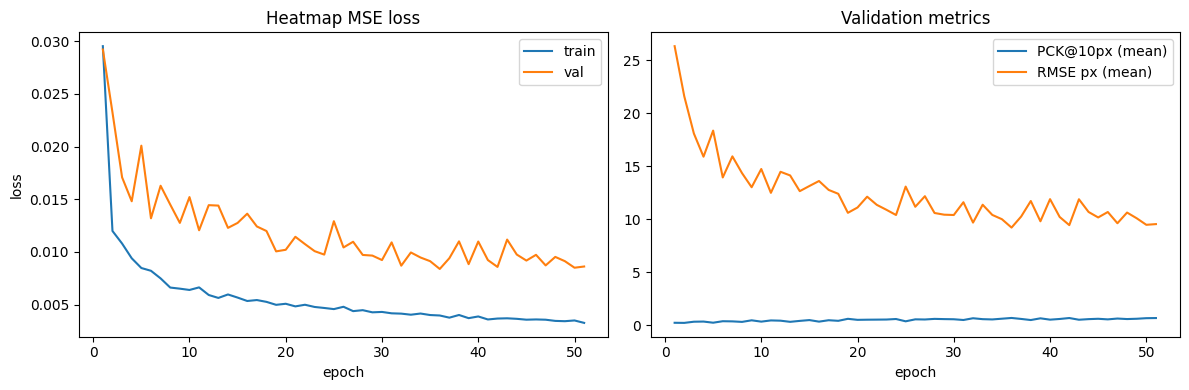

Best val RMSE: 9.21px
Checkpoint: checkpoints/best_model.pt


In [ ]:
history = result["history"]
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].set_title("Heatmap MSE loss")

axes[1].plot(epochs, history["val_pck_mean"], label="PCK@10px (mean)")
axes[1].plot(epochs, history["val_rmse_mean"], label="RMSE px (mean)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].set_title("Validation metrics") 

plt.tight_layout()
plt.show()

print(f"Best val RMSE: {result['best_val_rmse']:.2f}px")
print(f"Checkpoint: {Path(result['out_dir']) / 'best_model.pt'}")